B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\aptos19_sorted\NO_DR\0a38b552372d_0.png

Procesam imaginea: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\aptos19_sorted\NO_DR\cd8da43e3069_0.png


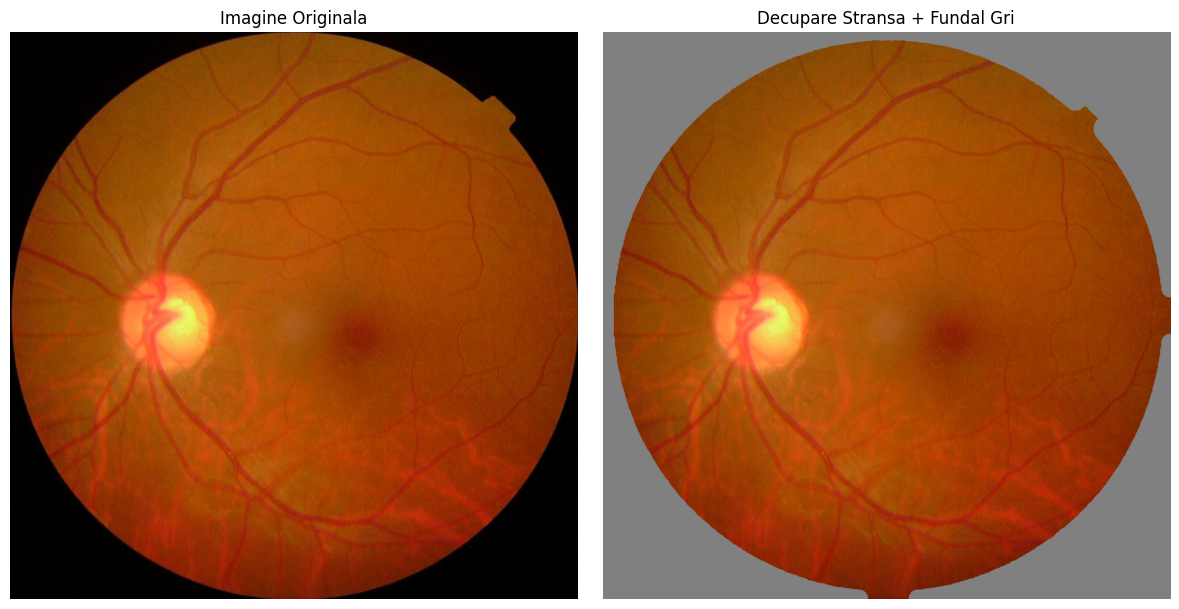

Procesam imaginea: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\aptos19_sorted\NO_DR\b72a86d61959_0.png


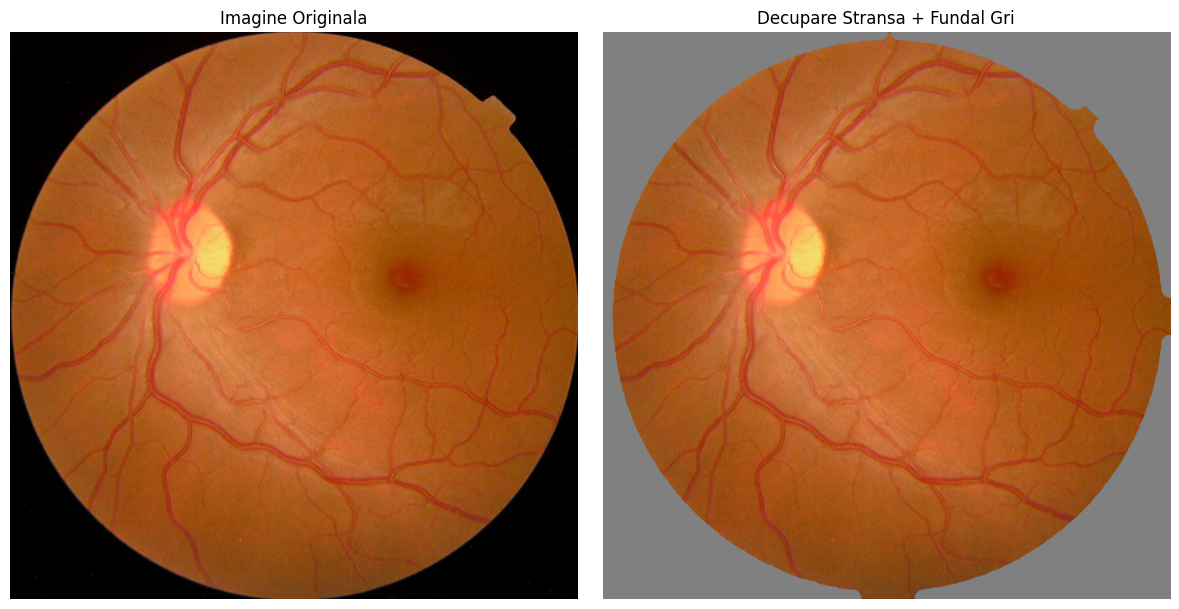

Procesam imaginea: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\aptos19_sorted\NO_DR\992599744a23_0.png


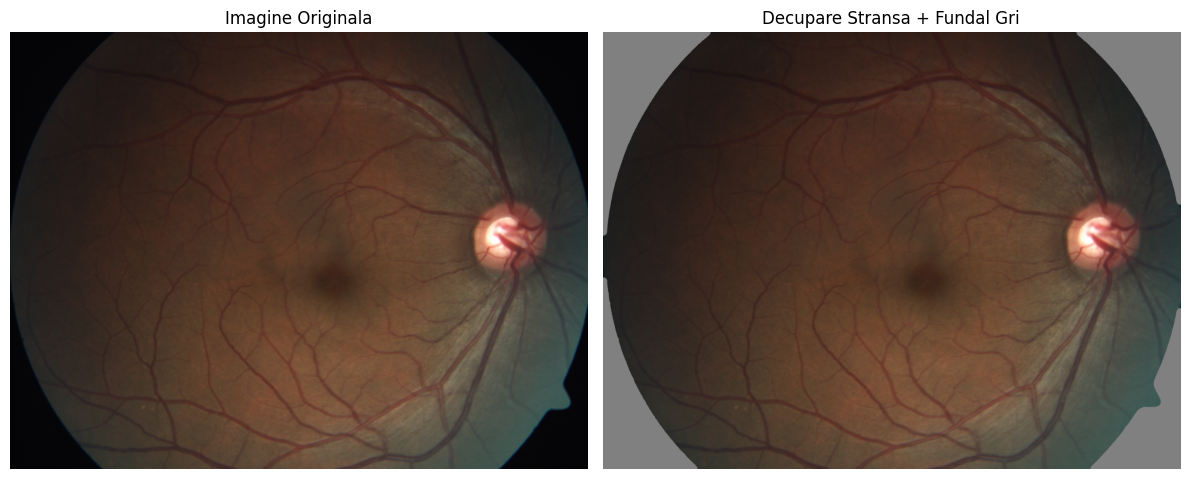

Procesam imaginea: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\aptos19_sorted\NO_DR\ec6659926105_0.png


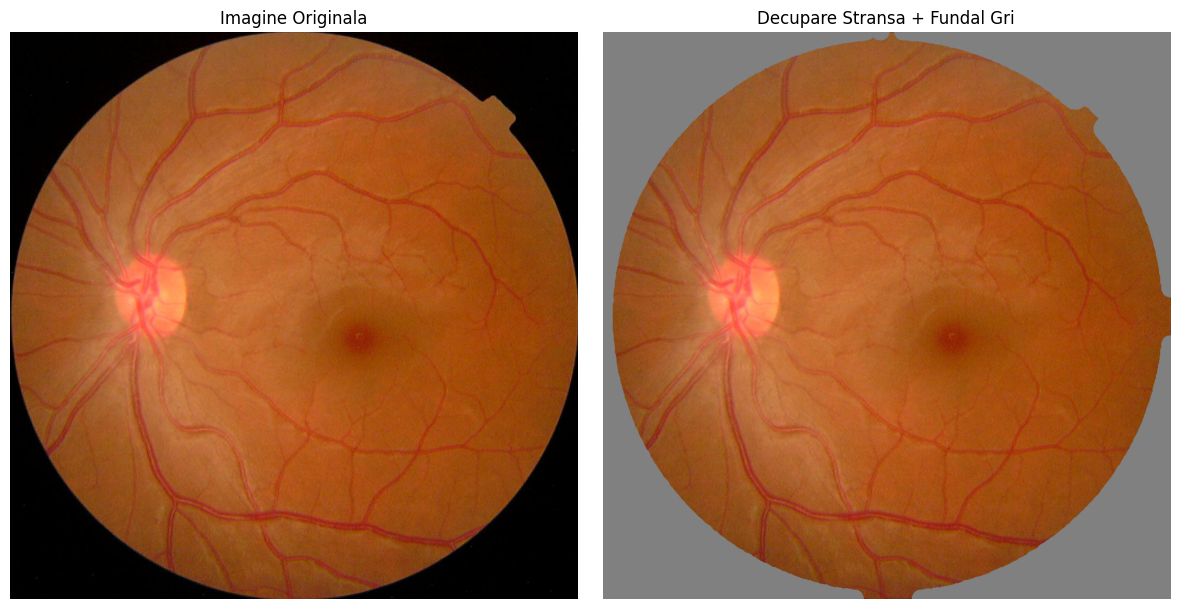

Procesam imaginea: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\aptos19_sorted\NO_DR\2cfe8703f265_0.png


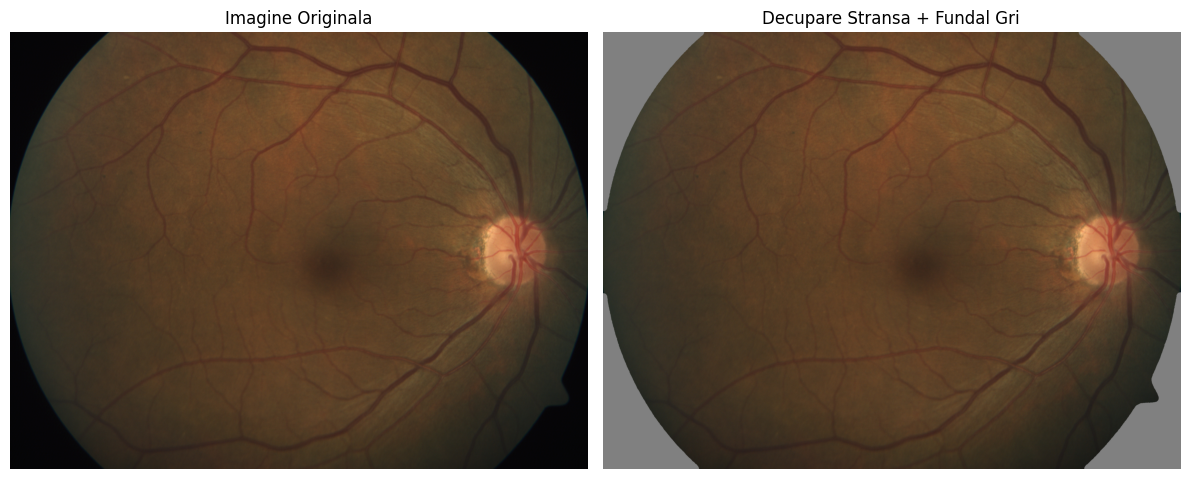

In [64]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def proceseaza_fundal_gri_strans(image_path):
    # 1. Incarcam imaginea
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Nu s-a gasit imaginea la calea: {image_path}")

    # =========================================================
    # PASUL 1: Extragerea inteligenta a mastii
    # =========================================================
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Gasim zona luminoasa
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    
    # Curatam zgomotele si artefactele de pe fundal
    kernel_clean = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    thresh_clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_clean)
    
    # Gasim contururile
    contours, _ = cv2.findContours(thresh_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        print("Avertisment: Nu s-a putut detecta conturul!")
        return img, img

    contur_ochi = max(contours, key=cv2.contourArea)
    
    # Desenam masca
    masca = np.zeros_like(gray)
    cv2.drawContours(masca, [contur_ochi], -1, 255, thickness=cv2.FILLED)

    # =========================================================
    # PASUL 2: TRUCUL NOU - Micsoram masca spre interior
    # =========================================================
    # Folosim o eroziune pentru a "musca" din marginea mastii.
    # Un kernel de 25x25 va taia aproximativ 12 pixeli din toata marginea.
    # Daca inca ramane negru, poti mari kernelul la (35, 35) sau chiar (45, 45).
    kernel_eroziune = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))
    masca_stransa = cv2.erode(masca, kernel_eroziune, iterations=1)

    # =========================================================
    # PASUL 3: Aplicarea fundalului gri
    # =========================================================
    rezultat_gri = np.full(img.shape, 128, dtype=np.uint8)
    
    # Extindem masca stransa la 3 canale
    masca_3d = masca_stransa[:, :, None] == 255
    
    # Lipim imaginea
    np.copyto(rezultat_gri, img, where=masca_3d)

    return img, rezultat_gri

def testeaza_script(cale_imagine):
    print(f"Procesam imaginea: {cale_imagine}")
    try:
        img_orig, img_final = proceseaza_fundal_gri_strans(cale_imagine)
        
        plt.figure(figsize=(12, 6))
        
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
        plt.title('Imagine Originala')
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
        plt.title('Decupare Stransa + Fundal Gri')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Eroare: {e}")

if __name__ == '__main__':
    # 5 imagini random din folderul B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\aptos19_sorted\NO_DR\ si afisem
    folder = r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\aptos19_sorted\NO_DR"
    imagini = [f for f in os.listdir(folder) if f.endswith(('.png', '.jpg', '.jpeg'))]
    
    # Selectam 5 imagini random
    imagini_random = np.random.choice(imagini, size=5, replace=False)

    for imagine in imagini_random:
        imagine_path = os.path.join(folder, imagine)
        if os.path.exists(imagine_path):
            testeaza_script(imagine_path)
        else:
            print(f"Calea catre imagine nu este corecta: {imagine_path}")

Procesam imaginea: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\aptos19_sorted\NO_DR\5baed382f062_0.png


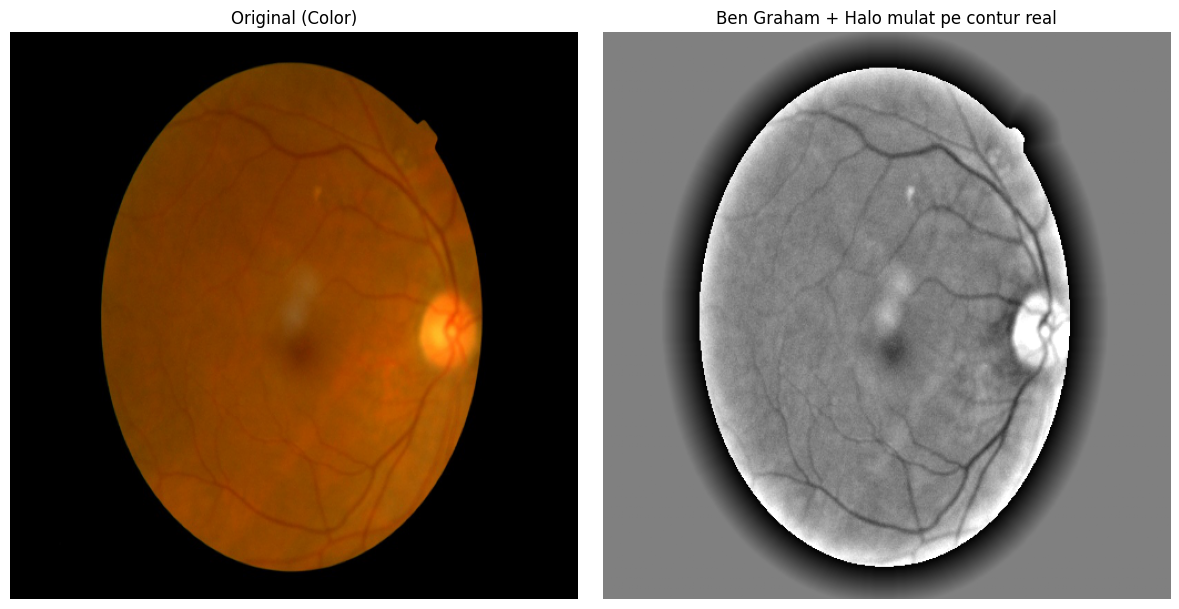

In [117]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def procesare_ben_graham_elipsa_halo(image_path, size=512):
    # 1. Incarcare si Resize
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Nu s-a gasit imaginea la calea: {image_path}")
    img_resized = cv2.resize(img, (size, size))
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    # =========================================================
    # PASUL 1: Detectia EXACTA a conturului real (oricare ar fi forma)
    # =========================================================
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    
    # Deschidere morfologica pentru a taia artefactele de la margini
    kernel_clean = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    thresh_clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_clean)
    
    contours, _ = cv2.findContours(thresh_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img_resized, gray

    # Desenam conturul real al ochiului (care poate fi elipsa)
    contur_ochi = max(contours, key=cv2.contourArea)
    masca_ochi = np.zeros((size, size), dtype=np.uint8)
    cv2.drawContours(masca_ochi, [contur_ochi], -1, 255, thickness=cv2.FILLED)
    
    # Taiem 5 pixeli din toata marginea spre interior ca sa scapam de marginile camerei
    # Un kernel de 11x11 erodeaza cam 5 pixeli pe fiecare parte
    kernel_eroziune = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    masca_ochi = cv2.erode(masca_ochi, kernel_eroziune, iterations=1)

    # =========================================================
    # PASUL 2: Transformarea BEN GRAHAM
    # =========================================================
    sigmaX = size / 30.0 
    blur = cv2.GaussianBlur(gray, (0, 0), sigmaX)
    ben_graham_gray = cv2.addWeighted(gray, 4, blur, -4, 128)

    # =========================================================
    # PASUL 3: Halo Exterior mulat pe forma exacta (Distance Transform)
    # =========================================================
    # Inversam masca (Ochiul devine 0, exteriorul devine 255)
    masca_exterior = cv2.bitwise_not(masca_ochi)
    
    # Aflam distanta fiecarui pixel de fundal fata de cea mai apropiata margine a ochiului
    dist = cv2.distanceTransform(masca_exterior, cv2.DIST_L2, 5)

    # Cat de gros sa fie gradientul (in pixeli) incepand de la contur
    halo_width = 35.0 

    # Plansa de baza: 128.0 (gri neutru)
    rezultat_final = np.full((size, size), 128.0, dtype=np.float32)

    # Identificam zona haloului (doar pixelii de afara aflati la distanta <= 35)
    halo_mask = (dist > 0) & (dist <= halo_width)
    
    # Gradient: la distanta 0 de marginea ochiului e 0.0 (negru), 
    # la distanta 35 de margine e 1.0 (care inmultit cu 128 da gri steril)
    fraction = dist[halo_mask] / halo_width
    rezultat_final[halo_mask] = 128.0 * fraction

    # Lipim ochiul prelucrat EXACT unde ii este masca interioara (dist == 0)
    interior_mask = (masca_ochi == 255)
    rezultat_final[interior_mask] = ben_graham_gray[interior_mask]

    # Convertim in imagine
    rezultat_final = rezultat_final.astype(np.uint8)

    return img_resized, rezultat_final

def testeaza_script(cale_imagine):
    print(f"Procesam imaginea: {cale_imagine}")
    try:
        img_orig, img_final = procesare_ben_graham_elipsa_halo(cale_imagine)
        
        plt.figure(figsize=(12, 6))
        
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
        plt.title('Original (Color)')
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        plt.imshow(img_final, cmap='gray', vmin=0, vmax=255)
        plt.title('Ben Graham + Halo mulat pe contur real')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Eroare: {e}")

if __name__ == '__main__':
    # Imaginea ta
    folder = r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\aptos19_sorted\NO_DR"
    imagini = [f for f in os.listdir(folder) if f.endswith(('.png', '.jpg', '.jpeg'))]
    imagine_random = np.random.choice(imagini, size=1, replace=False)[0]    
    
    if os.path.exists(os.path.join(folder, imagine_random)):
        testeaza_script(os.path.join(folder, imagine_random))
    else:
        print("Calea catre imagine nu este corecta!")

In [187]:
import os
from pathlib import Path

def verifica_dataset(cale_dataset):
    base_dir = Path(cale_dataset)
    
    if not base_dir.exists():
        print(f"Eroare: Folderul {base_dir} nu a fost gasit!")
        return

    # Setam split-urile si clasele pe care vrem sa le numaram
    splits = ["test", "train", "val"]
    classes = ["0", "1", "2", "3", "4"]
    extensii_imagini = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

    # Structura de date pentru a tine evidenta: dictionar in dictionar
    # ex: counts["0"]["train"] = 1800
    counts = {cls: {split: 0 for split in splits} for cls in classes}

    # Culegem datele din foldere
    for split in splits:
        for cls in classes:
            folder_path = base_dir / split / cls
            if folder_path.exists() and folder_path.is_dir():
                # Numaram doar fisierele cu extensii de imagine
                num_images = sum(
                    1 for file in folder_path.iterdir() 
                    if file.is_file() and file.suffix.lower() in extensii_imagini
                )
                counts[cls][split] = num_images

    # Afisam exact in formatul cerut de tine
    print(f"{cale_dataset}")
    for cls in classes:
        print(f"Class {cls}:")
        print(f"\t-> test:  {counts[cls]['test']}")
        print(f"\t-> train: {counts[cls]['train']}")
        print(f"\t-> val:   {counts[cls]['val']}\n")

    print("-" * 40 + "\n")

if __name__ == "__main__":
    # Schimba aici cu calea catre dataset-ul tau
    verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\Diabetic_Balanced_Data")

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\Diabetic_Balanced_Data
Class 0:
	-> test:  1000
	-> train: 7000
	-> val:   2000

Class 1:
	-> test:  971
	-> train: 6792
	-> val:   1940

Class 2:
	-> test:  1000
	-> train: 7000
	-> val:   2000

Class 3:
	-> test:  1000
	-> train: 7000
	-> val:   2000

Class 4:
	-> test:  1000
	-> train: 7000
	-> val:   2000

----------------------------------------



In [145]:
verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\Diabetic_Balanced_Aug_resized_train")
verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\Diabetic_Balanced_Aug_resized_train_cropped")

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\Diabetic_Balanced_Aug_resized_train
Class 0:
	-> test:  0
	-> train: 25810
	-> val:   0

Class 1:
	-> test:  0
	-> train: 2443
	-> val:   0

Class 2:
	-> test:  0
	-> train: 5292
	-> val:   0

Class 3:
	-> test:  0
	-> train: 873
	-> val:   0

Class 4:
	-> test:  0
	-> train: 708
	-> val:   0

----------------------------------------

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\Diabetic_Balanced_Aug_resized_train_cropped
Class 0:
	-> test:  0
	-> train: 25802
	-> val:   0

Class 1:
	-> test:  0
	-> train: 2438
	-> val:   0

Class 2:
	-> test:  0
	-> train: 5288
	-> val:   0

Class 3:
	-> test:  0
	-> train: 872
	-> val:   0

Class 4:
	-> test:  0
	-> train: 708
	-> val:   0

----------------------------------------



In [133]:
verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\my_dataset")

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\my_dataset
Class 0:
	-> test:  3864
	-> train: 27054
	-> val:   7728

Class 1:
	-> test:  3864
	-> train: 27054
	-> val:   7728

Class 2:
	-> test:  3864
	-> train: 27054
	-> val:   7728

Class 3:
	-> test:  3864
	-> train: 27054
	-> val:   7728

Class 4:
	-> test:  3864
	-> train: 27054
	-> val:   7728

----------------------------------------



In [144]:
verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\Diabetic_Balanced_Data_original")
verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\Diabetic_Balanced_Data_augmented")

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\Diabetic_Balanced_Data_original
Class 0:
	-> test:  722
	-> train: 5021
	-> val:   1471

Class 1:
	-> test:  234
	-> train: 1742
	-> val:   467

Class 2:
	-> test:  528
	-> train: 3495
	-> val:   988

Class 3:
	-> test:  56
	-> train: 453
	-> val:   128

Class 4:
	-> test:  66
	-> train: 461
	-> val:   120

----------------------------------------

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\Diabetic_Balanced_Data_augmented
Class 0:
	-> test:  278
	-> train: 1979
	-> val:   529

Class 1:
	-> test:  737
	-> train: 5050
	-> val:   1473

Class 2:
	-> test:  472
	-> train: 3505
	-> val:   1012

Class 3:
	-> test:  944
	-> train: 6547
	-> val:   1872

Class 4:
	-> test:  934
	-> train: 6539
	-> val:   1880

----------------------------------------



In [191]:
verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\balanced_aug_new\Final_split_dataset")
verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\balanced_aug_new\final_augmented+ben_graham_dataset")

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\balanced_aug_new\Final_split_dataset
Class 0:
	-> test:  761
	-> train: 5321
	-> val:   1520

Class 1:
	-> test:  228
	-> train: 1597
	-> val:   456

Class 2:
	-> test:  467
	-> train: 3267
	-> val:   933

Class 3:
	-> test:  75
	-> train: 528
	-> val:   151

Class 4:
	-> test:  54
	-> train: 377
	-> val:   108

----------------------------------------

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\balanced_aug_new\final_augmented+ben_graham_dataset
Class 0:
	-> test:  1054
	-> train: 7418
	-> val:   2066

Class 1:
	-> test:  1054
	-> train: 7418
	-> val:   2066

Class 2:
	-> test:  1054
	-> train: 7418
	-> val:   2066

Class 3:
	-> test:  1054
	-> train: 7418
	-> val:   2066

Class 4:
	-> test:  1054
	-> train: 7418
	-> val:   2066

----------------------------------------



In [192]:
verifica_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\aptos_new\final_aptos_augmented+ben_graham_dataset")

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\aptos_new\final_aptos_augmented+ben_graham_dataset
Class 0:
	-> test:  190
	-> train: 1330
	-> val:   379

Class 1:
	-> test:  190
	-> train: 1330
	-> val:   379

Class 2:
	-> test:  190
	-> train: 1330
	-> val:   379

Class 3:
	-> test:  190
	-> train: 1330
	-> val:   379

Class 4:
	-> test:  190
	-> train: 1330
	-> val:   379

----------------------------------------



In [140]:
# Show number of images from cleaned_dataset (only 0/1/2/3/4 structure)
from matplotlib.pylab import split


def verifica_dataset_2(cale_dataset):
    base_dir = Path(cale_dataset)
    
    if not base_dir.exists():
        print(f"Eroare: Folderul {base_dir} nu a fost gasit!")
        return

    # Setam split-urile si clasele pe care vrem sa le numaram
    classes = ["0", "1", "2", "3", "4"]
    extensii_imagini = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

    # Structura de date pentru a tine evidenta: dictionar in dictionar
    # ex: counts["0"] = 1800
    counts = {cls: 0 for cls in classes}

    # Culegem datele din foldere
    for cls in classes:
        folder_path = base_dir / cls
        if folder_path.exists() and folder_path.is_dir():
            # Numaram doar fisierele cu extensii de imagine
            num_images = sum(
                1 for file in folder_path.iterdir() 
                if file.is_file() and file.suffix.lower() in extensii_imagini
            )
            counts[cls] = num_images

    # Afisam exact in formatul cerut de tine
    print(f"{cale_dataset}")
    for cls in classes:
        print(f"Class {cls}:")
        print(f"\t-> train: {counts[cls]}")

    print("-" * 40 + "\n")

if __name__ == "__main__":
    # Schimba aici cu calea catre dataset-ul tau
    verifica_dataset_2(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\cleaned_dataset")

B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\cleaned_dataset
Class 0:
	-> train: 11469
Class 1:
	-> train: 1198
Class 2:
	-> train: 1979
Class 3:
	-> train: 327
Class 4:
	-> train: 221
----------------------------------------



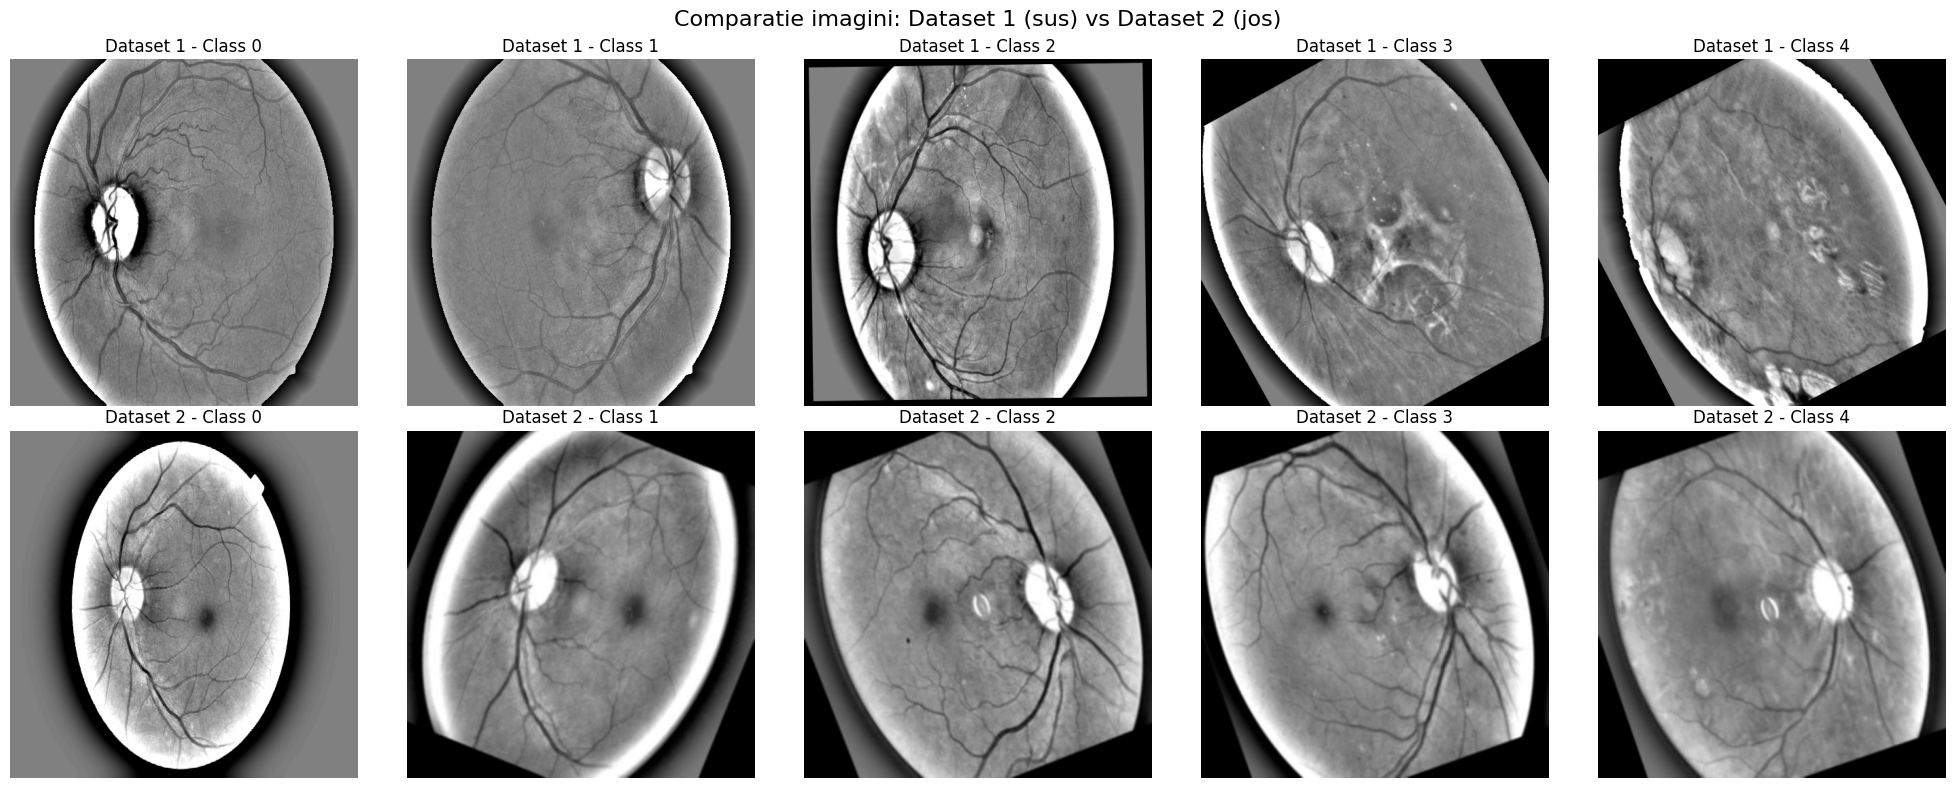

In [219]:
# Show 5 images (1 from each class) for 2 different datasets: 2 subplots with 1 line and 5 columns, each column is a class (0/1/2/3/4) and each line is a dataset (ex: original vs augmented)
def arata_imagini_random_diferite_dataseturi(cale_dataset_1, cale_dataset_2):
    classes = ["0", "1", "2", "3", "4"]
    extensii_imagini = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle("Comparatie imagini: Dataset 1 (sus) vs Dataset 2 (jos)", fontsize=16)

    for col, cls in enumerate(classes):
        # Dataset 1
        folder_1 = Path(cale_dataset_1) / cls
        imagini_1 = [f for f in folder_1.iterdir() if f.is_file() and f.suffix.lower() in extensii_imagini]
        if imagini_1:
            img_1 = cv2.imread(str(np.random.choice(imagini_1)))
            img_1_rgb = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)
            axes[0, col].imshow(img_1_rgb)
            axes[0, col].set_title(f"Dataset 1 - Class {cls}")
            axes[0, col].axis('off')
        else:
            axes[0, col].set_title(f"Dataset 1 - Class {cls}\n(No images)")
            axes[0, col].axis('off')

        # Dataset 2
        folder_2 = Path(cale_dataset_2) / cls
        imagini_2 = [f for f in folder_2.iterdir() if f.is_file() and f.suffix.lower() in extensii_imagini]
        if imagini_2:
            img_2 = cv2.imread(str(np.random.choice(imagini_2)))
            img_2_rgb = cv2.cvtColor(img_2, cv2.COLOR_BGR2RGB)
            axes[1, col].imshow(img_2_rgb)
            axes[1, col].set_title(f"Dataset 2 - Class {cls}")
            axes[1, col].axis('off')
        else:
            axes[1, col].set_title(f"Dataset 2 - Class {cls}\n(No images)")
            axes[1, col].axis('off')

    plt.tight_layout()
    plt.show()
    
if __name__ == "__main__":
    arata_imagini_random_diferite_dataseturi(
        r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\balanced_aug_new\final_balanced_augmented+ben_graham_dataset\train",
        r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\Diabetic_Balanced_Data\train"
    )